<table>
    <tr>
        <td><img src="https://raw.githubusercontent.com/Fabian830348/Bases_Datos/refs/heads/master/logo_ECI.png" width="300"/></td>
        <td>&nbsp;</td>
        <td>
            <h1 style="font-size:200%;color:blue;text-align:center">    <FONT COLOR="blue">  Entregable 3   </p> K-means y PCA </p> Métodos de ensamble </FONT>         </h1></td>         
        <td>
            <tp><p style="font-size:99%;text-align:center">Aprendizaje Automático de Máquina </p></tp>
            <tp><p style="font-size:115%;text-align:center">Pregrado MACC 2026-1</p></tp>
            <tp><p style="font-size:115%;text-align:center">Prof. Fabián Sánchez</p></tp>
        </td>
    </tr>
</table>

# <FONT SIZE=5 COLOR="purple"> **Indicaciones** </FONT>

- Para entregar en grupo de dos o tres integrantes (únicamente)

- **Importante:** Cargar en la plataforma *e-aulas* los **dos** archivos: ***.ipynb*** y ***.pdf***

- Fecha de entrega el día **miércoles 6 de Mayo 11:59 p.m.**

- Nombrar los trabajos de la siguiente manera:

Caso_3_ML_2026_(nombre 1-nombre 2-nombre 3)

- En el notebook, indicar el nombre de los integrantes del grupo.

**Nota**: El incumplimiento de alguna de las condiciones anteriores tiene una penalidad de 0.5 en la nota del entregable.



# <FONT COLOR="Purple"> 1. PCA</FONT>

El objetivo de este ejercicio es agrupar países basándose en diversas características numéricas, como indicadores económicos, factores de salud y parámetros sociales. Este es un problema de aprendizaje no supervisado porque no se cuenta con categorías o etiquetas predefinidas para los países.


```python
https://raw.githubusercontent.com/Fabian830348/Bases_Datos/refs/heads/master/datos_paises.csv
```

Las variables significan lo siguiente:

- **País**: Nombre del país.
- **Mortalidad infantil**: Muerte de niños menores de 5 años por cada 1000 - nacidos vivos.
- **Exportaciones**: Exportaciones de bienes y servicios per cápita. Expresadas como porcentaje del PIB per cápita.
- **Salud**:Gasto total en salud per cápita. Expresado como porcentaje del PIB per cápita.
- **Importaciones**: Importaciones de bienes y servicios per cápita. Expresadas como porcentaje del PIB per cápita.
- **Ingresos**: Ingreso neto anual por persona.
- **Inflación**: Medida de la tasa de crecimiento anual del PIB total.
- **Esperanza de vida**: Número promedio de años que viviría un recién nacido si los patrones actuales de mortalidad permanecen iguales.
- **Fertilidad total**: Número de hijos que tendría cada mujer si las tasas actuales de fertilidad por edad permanecen iguales.
- **PIB per cápita (GDPP)**: Producto Interno Bruto por persona. Calculado como el PIB total dividido entre la población total.


1. Cargar y explorar los datos

2. Hacer el analisis de PCA. Identificar las componentes.

3. Hacer el análisis de Biplot.

4. Concluya

## 1.1 Librerías

In [1]:
import numpy  as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn           as sns
import plotly.express    as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio # Import plotly.io
pio.renderers.default = 'colab' # Set default renderer for Colab

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics       import silhouette_score, silhouette_samples
from sklearn.cluster       import KMeans
from sklearn.neighbors     import NearestNeighbors
from sklearn.metrics       import pairwise_distances_argmin_min

from yellowbrick.cluster import KElbowVisualizer

import warnings
warnings.filterwarnings("ignore")

In [2]:
#para importar la librería pandas.
import pandas    as pd
import numpy     as np

# librerías para gráficar
import matplotlib.pyplot    as plt
import plotly.express       as px
import seaborn              as sns

# estandarizar los datos
from sklearn.preprocessing import StandardScaler
# importamos la librería para pca clásica
from sklearn.decomposition import PCA
# importamos el escalador estándar
from sklearn.preprocessing import StandardScaler

In [3]:
import plotly.io as pio
pio.renderers.default = 'colab' # Set default renderer for Colab to ensure inline display

## 1.2 Cargar y explorar los datos

In [4]:
url = "https://raw.githubusercontent.com/Fabian830348/Bases_Datos/refs/heads/master/datos_paises.csv"
df = pd.read_csv(url)
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [5]:
df.shape

(167, 10)

In [6]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [7]:
df.dtypes

,0
country,object
child_mort,float64
exports,float64
health,float64
imports,float64
income,int64
inflation,float64
life_expec,float64
total_fer,float64
gdpp,int64


In [8]:
def boxplots_variables_numericas_plotly(df):
    df_numerico = df.select_dtypes(include=['number']).drop(columns=['CustomerID'], errors='ignore')

    if df_numerico.empty:
        print(" No hay columnas numéricas para graficar")
        return

    print("Columnas numéricas:", df_numerico.columns.tolist())

    df_long = df_numerico.melt(var_name='Variable', value_name='Valor')

    fig = px.box(df_long,
                 x='Variable',
                 y='Valor',
                 color='Variable',
                 facet_col='Variable',
                 facet_col_wrap=3,
                 title='Boxplots de Variables Numéricas')

    fig.update_xaxes(showticklabels=False)
    fig.update_layout(height=700, width=1000)
    fig.show()

In [9]:
boxplots_variables_numericas_plotly(df)

Columnas numéricas: ['child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']


In [10]:
# existencia de NA (datos faltantes)
df.isna().sum()

,0
country,0
child_mort,0
exports,0
health,0
imports,0
income,0
inflation,0
life_expec,0
total_fer,0
gdpp,0


In [11]:
# Debemos trabajar con datos no nulos. En esta ocasión los vamos a omitir
df2 = df.dropna()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [12]:
# vemos la cabeza de los datos
df2.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [13]:
df2

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200
...,...,...,...,...,...,...,...,...,...,...
162,Vanuatu,29.2,46.6,5.25,52.7,2950,2.62,63.0,3.50,2970
163,Venezuela,17.1,28.5,4.91,17.6,16500,45.90,75.4,2.47,13500
164,Vietnam,23.3,72.0,6.84,80.2,4490,12.10,73.1,1.95,1310
165,Yemen,56.3,30.0,5.18,34.4,4480,23.60,67.5,4.67,1310


## 1.3 Estandarización

In [14]:
# escalar los datos
df2_numeric = df2.select_dtypes(include=np.number)
df2_std = StandardScaler().fit_transform(df2_numeric)
df2_std

array([[ 1.29153238, -1.13827979,  0.27908825, ..., -1.61909203,
         1.90288227, -0.67917961],
       [-0.5389489 , -0.47965843, -0.09701618, ...,  0.64786643,
        -0.85997281, -0.48562324],
       [-0.27283273, -0.09912164, -0.96607302, ...,  0.67042323,
        -0.0384044 , -0.46537561],
       ...,
       [-0.37231541,  1.13030491,  0.0088773 , ...,  0.28695762,
        -0.66120626, -0.63775406],
       [ 0.44841668, -0.40647827, -0.59727159, ..., -0.34463279,
         1.14094382, -0.63775406],
       [ 1.11495062, -0.15034774, -0.33801514, ..., -2.09278484,
         1.6246091 , -0.62954556]])

In [15]:
# revisamos la matriz de correlaciones
pd.DataFrame(df2_std , index = df2.index , columns = df2_numeric.columns).corr()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
child_mort,1.000000,-0.318093,-0.200402,-0.127211,-0.524315,0.288276,-0.886676,0.848478,-0.483032
exports,-0.318093,1.000000,-0.114408,0.737381,0.516784,-0.107294,0.316313,-0.320011,0.418725
health,-0.200402,-0.114408,1.000000,0.095717,0.129579,-0.255376,0.210692,-0.196674,0.345966
imports,-0.127211,0.737381,0.095717,1.000000,0.122406,-0.246994,0.054391,-0.159048,0.115498
income,-0.524315,0.516784,0.129579,0.122406,1.000000,-0.147756,0.611962,-0.501840,0.895571
inflation,0.288276,-0.107294,-0.255376,-0.246994,-0.147756,1.000000,-0.239705,0.316921,-0.221631
life_expec,-0.886676,0.316313,0.210692,0.054391,0.611962,-0.239705,1.000000,-0.760875,0.600089
total_fer,0.848478,-0.320011,-0.196674,-0.159048,-0.501840,0.316921,-0.760875,1.000000,-0.454910
gdpp,-0.483032,0.418725,0.345966,0.115498,0.895571,-0.221631,0.600089,-0.454910,1.000000


## 1.4 Análisis de PCA

In [16]:
# Definimos el objeto PCA y determinamos el número de componentes principales que deseamos.
pca = PCA(n_components= 0.85)                 # Otra opcion pca = PCA(n_components = 0.85).
pca.fit(df2_std)                      # Ajuste ese PCA a los datos estandarizados.
pca_proj = pca.transform(df2_std)     # calcula las nuevas variables que son combinación lineal de las originales
pca_proj

array([[-2.91302459e+00,  9.56205755e-02, -7.18118495e-01,
         1.00525464e+00],
       [ 4.29911330e-01, -5.88155666e-01, -3.33485505e-01,
        -1.16105859e+00],
       [-2.85225077e-01, -4.55174413e-01,  1.22150481e+00,
        -8.68114503e-01],
       [-2.93242265e+00,  1.69555507e+00,  1.52504374e+00,
         8.39625014e-01],
       [ 1.03357587e+00,  1.36658709e-01, -2.25720917e-01,
        -8.47062687e-01],
       [ 2.24072616e-02, -1.77918658e+00,  8.69997116e-01,
        -3.69668667e-02],
       [-1.01583737e-01, -5.68251724e-01,  2.42091816e-01,
        -1.46626576e+00],
       [ 2.34216461e+00, -1.98845915e+00,  1.90344188e-01,
         1.10503778e+00],
       [ 2.97376366e+00, -7.34688659e-01, -5.19766356e-01,
         1.20544210e+00],
       [-1.81486997e-01, -4.02865873e-01,  8.67458743e-01,
        -4.38772983e-01],
       [ 1.26874386e+00, -6.56588363e-01, -4.88097616e-01,
         5.56335553e-02],
       [ 1.67099640e+00,  5.61162493e-01,  9.91258303e-01,
      

In [17]:
pca.components_

array([[-0.41951945,  0.28389698,  0.15083782,  0.16148244,  0.39844111,
        -0.19317293,  0.42583938, -0.40372896,  0.39264482],
       [ 0.19288394,  0.61316349, -0.24308678,  0.67182064,  0.02253553,
        -0.00840447, -0.22270674,  0.15523311, -0.0460224 ],
       [-0.02954353,  0.14476069, -0.59663237, -0.29992674,  0.3015475 ,
         0.64251951,  0.11391854,  0.01954925,  0.12297749],
       [ 0.37065326,  0.00309102,  0.4618975 , -0.07190746,  0.39215904,
         0.15044176, -0.20379723,  0.37830365,  0.53199457]])

In [18]:
proyecciones = pd.DataFrame(pca_proj,
                            columns = [f'PC{i+1}' for i in range(pca_proj.shape[1])],
                            index   = df2.index)
proyecciones.head(10)

,PC1,PC2,PC3,PC4
0,-2.913025,0.095621,-0.718118,1.005255
1,0.429911,-0.588156,-0.333486,-1.161059
2,-0.285225,-0.455174,1.221505,-0.868115
3,-2.932423,1.695555,1.525044,0.839625
4,1.033576,0.136659,-0.225721,-0.847063
5,0.022407,-1.779187,0.869997,-0.036967
6,-0.101584,-0.568252,0.242092,-1.466266
7,2.342165,-1.988459,0.190344,1.105038
8,2.973764,-0.734689,-0.519766,1.205442
9,-0.181487,-0.402866,0.867459,-0.438773


In [19]:
proyecciones.corr()

,PC1,PC2,PC3,PC4
PC1,1.000000e+00,1.109381e-16,-3.233265e-17,3.670921e-17
PC2,1.109381e-16,1.000000e+00,4.336341e-17,2.706869e-16
PC3,-3.233265e-17,4.336341e-17,1.000000e+00,2.663178e-16
PC4,3.670921e-17,2.706869e-16,2.663178e-16,1.000000e+00


In [20]:
# para ver la varianza explicada
pca.explained_variance_ratio_

array([0.4595174 , 0.17181626, 0.13004259, 0.11053162])

In [21]:
# Cantidad de varianza retenida por las 2 primeras componentes principales.
ratio = np.sum(pca.explained_variance_ratio_)
print(f"\nLa cantidad de variabilidad retenida por las 2 primeras componentes es {ratio*100:.3f}%")


La cantidad de variabilidad retenida por las 2 primeras componentes es 87.191%


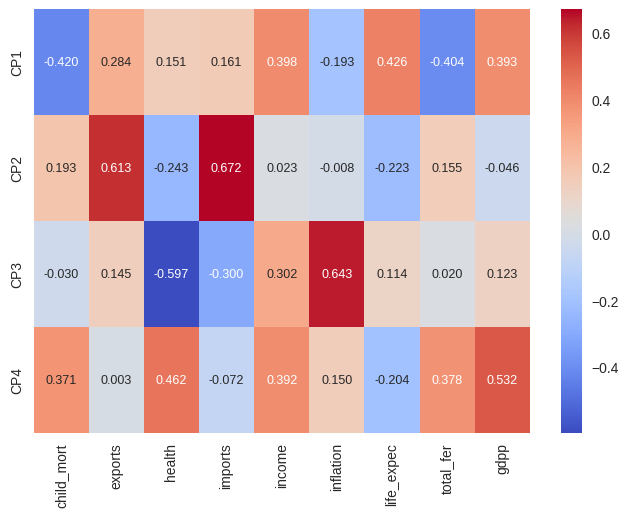

<Figure size 1200x500 with 0 Axes>

In [22]:
sns.heatmap(pca.components_,
            xticklabels=df2_numeric.columns,
            yticklabels=["CP1", "CP2", "CP3", "CP4"],
            cmap="coolwarm",
            fmt=".3f",
            annot=True,
            annot_kws={"size": 9})
plt.figure(figsize=(12, 5))
plt.tight_layout()
plt.show()

## <FONT SIZE=4 COLOR="green"> ANÁLISIS </FONT>

CP1 captura el eje de desarrollo humano: carga negativa fuerte en `life_expec` y positiva en `child_mort` y `total_fer`, separando países desarrollados de subdesarrollados. CP2 está dominada por `exports` e `imports`, representando apertura comercial. CP3 refleja principalmente la `inflation`. CP4 integra `income` y `gdpp`, capturando prosperidad económica absoluta. En conjunto las 4 componentes explican el 87.19% de la varianza total.

## 1.5 Varianza explicada acumulada

In [23]:
# Definimos el objeto PCA y determinamos el número de componentes principales que deseamos.
pca3 = PCA(n_components=3)                     # Otra opcion pca = PCA(n_components = 0.85).
pca3.fit(df2_std)                          # Ajuste ese PCA a los datos estandarizados.
pca3_proj = pca3.transform(df2_std)        # calcula las nuevas variables que son combinación lineal de las originales

In [24]:
proyecciones3 = pd.DataFrame(pca3.transform(df2_std),
                             columns = ["PC1", "PC2","PC3"],
                             index   = df2.index
)
proyecciones3.head(10)

,PC1,PC2,PC3
0,-2.913025,0.095621,-0.718118
1,0.429911,-0.588156,-0.333486
2,-0.285225,-0.455174,1.221505
3,-2.932423,1.695555,1.525044
4,1.033576,0.136659,-0.225721
5,0.022407,-1.779187,0.869997
6,-0.101584,-0.568252,0.242092
7,2.342165,-1.988459,0.190344
8,2.973764,-0.734689,-0.519766
9,-0.181487,-0.402866,0.867459


------------------------------------------
Porcentaje de varianza explicada acumulada
------------------------------------------
[0.4595174  0.63133365 0.76137624]


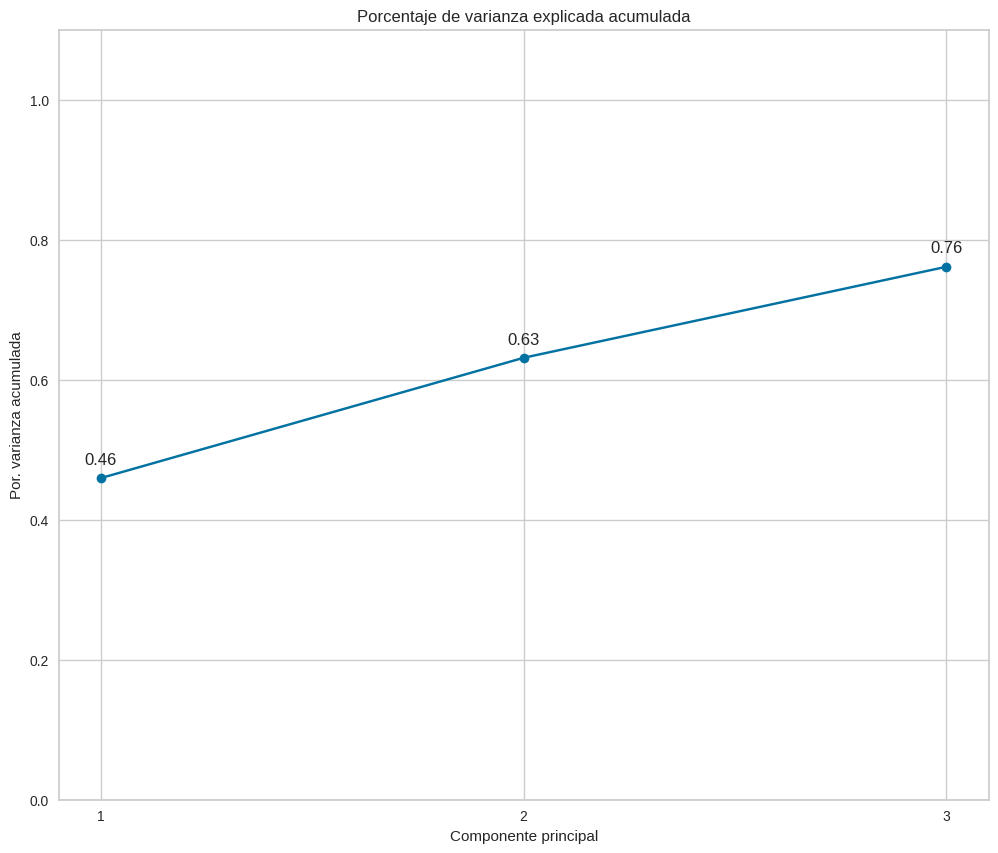

In [25]:
# Porcentaje de varianza explicada acumulada
# ==============================================================================
prop_varianza_acum = pca3.explained_variance_ratio_.cumsum()
print('------------------------------------------')
print('Porcentaje de varianza explicada acumulada')
print('------------------------------------------')
print(prop_varianza_acum)

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12, 10))
ax.plot(
    np.arange(len(proyecciones3.columns)) + 1,
    prop_varianza_acum,
    marker = 'o'
)

for x, y in zip(np.arange(len(proyecciones3.columns)) + 1, prop_varianza_acum): # hacer las proyecciones
    label = round(y, 2)
    ax.annotate(
        label,
        (x,y),
        textcoords="offset points",
        xytext=(0,10),
        ha='center'
    )

ax.set_ylim(0, 1.1)
ax.set_xticks(np.arange(pca3.n_components_) + 1)
ax.set_title('Porcentaje de varianza explicada acumulada')
ax.set_xlabel('Componente principal')
ax.set_ylabel('Por. varianza acumulada');

## <FONT SIZE=4 COLOR="green"> ANÁLISIS </FONT>

Con solo 3 componentes se retiene el 76.1% de la información original, y con las 4 componentes que seleccionó automáticamente el PCA (`n_components=0.85`) se alcanza el 87.2%. Esto confirma que la estructura del dataset puede resumirse eficientemente en pocas dimensiones sin pérdida significativa de información.

## 1.6 Proyección de países

In [26]:
fig = px.scatter_3d(proyecciones3,
                    x="PC1",
                    y= "PC2",
                    z= "PC3",
                   hover_name= df2.index,
                   text=df2.index,
                   labels={'0': 'PC 1', '1': 'PC 2', '2': 'PC 3'})
fig.show()

In [27]:
fig=px.scatter(proyecciones,
               x="PC1",
               y="PC2",
               hover_name=proyecciones.index,
               text=proyecciones.index)
fig.show()

## <FONT SIZE=4 COLOR="green"> ANÁLISIS </FONT>

Los países se distribuyen a lo largo de PC1 principalmente, confirmando que el eje de desarrollo humano es la mayor fuente de variación. Se identifican outliers claros como los índices 133, 91 y 98, que corresponden a países con perfiles extremos en mortalidad infantil, exportaciones o ingreso. La dispersión horizontal (PC1) es mayor que la vertical (PC2), consistente con que PC1 explica mayor proporción de varianza.

## 1.7 Biplot

In [28]:
!pip install pca
#bipots

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 190.4/190.4 kB 7.1 MB/s eta 0:00:00


In [29]:
from pca import pca

In [30]:
model = pca(n_components=2, normalize=True)
out = model.fit_transform(df2_std)

[09-05-2026 17:11:55] [pca.pca] [INFO] Column labels are auto-completed.
[09-05-2026 17:11:55] [pca.pca] [INFO] Row labels are auto-completed.
[09-05-2026 17:11:55] [pca.pca] [INFO] Normalizing input data per feature (zero mean and unit variance)..
[09-05-2026 17:11:55] [pca.pca] [INFO] The PCA reduction is performed on 9 variables (columns) of the input dataframe.
[09-05-2026 17:11:55] [pca.pca] [INFO] Fit using PCA.
[09-05-2026 17:11:55] [pca.pca] [INFO] Compute loadings and PCs.
[09-05-2026 17:11:55] [pca.pca] [INFO] Compute explained variance.
[09-05-2026 17:11:55] [pca.pca] [INFO] Outlier detection using Hotelling T2 test with alpha=[0.05] and n_components=[2]
[09-05-2026 17:11:55] [pca.pca] [INFO] Multiple test correction applied for Hotelling T2 test: [fdr_bh]
[09-05-2026 17:11:55] [pca.pca] [INFO] Outlier detection using SPE/DmodX with n_std=[3]


[09-05-2026 17:11:55] [pca.pca] [WARNING] Parameter <label> is deprecated and will not be supported in future version.
[09-05-2026 17:11:55] [pca.pca] [INFO] Plot PC1 vs PC2 with loadings.
[09-05-2026 17:11:55] [scatterd.scatterd] [INFO] Create scatterplot


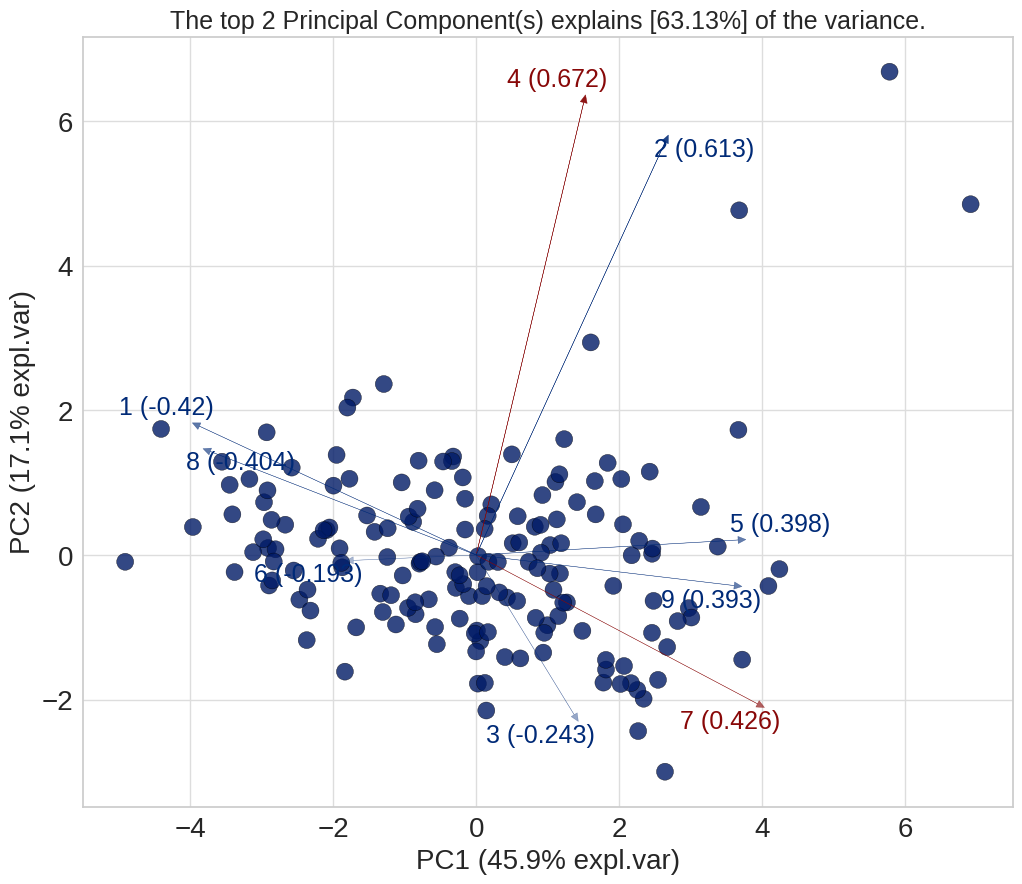

In [31]:
# para hacer el biplot
fig, ax = model.biplot(label=True,
                       legend=True,
                       figsize=(12, 10))

## <FONT SIZE=4 COLOR="green"> ANÁLISIS </FONT>

Los vectores de `life_expec` y `child_mort` apuntan en direcciones opuestas sobre PC1, confirmando su correlación negativa. `exports` e `imports` se alinean positivamente con PC2. Los países en el cuadrante superior derecho combinan alta esperanza de vida con alta apertura comercial. Los vectores más largos (`child_mort`, `life_expec`, `exports`) son los de mayor capacidad explicativa dentro del plano.

## <FONT SIZE=4 COLOR="green"> Conclusiones </FONT>
En conclusión, el Análisis de Componentes Principales permitió reducir eficazmente la complejidad del conjunto de datos, logrando que los dos primeros componentes expliquen el 63.13% de la variabilidad total y que tres componentes superen el 76%, lo cual demuestra que gran parte de la información original puede representarse mediante un número reducido de dimensiones. Los resultados evidencian que las principales diferencias entre los países analizados están determinadas por factores económicos, sociales, sanitarios y demográficos, donde variables como PIB, ingreso, salud, mortalidad infantil, inflación, fertilidad y esperanza de vida desempeñan un papel fundamental. El primer componente refleja principalmente contrastes asociados al desarrollo económico y estabilidad macroeconómica, mientras que el segundo componente se relaciona con bienestar social y condiciones de salud pública. Asimismo, la proyección de las observaciones permitió identificar tanto grupos con características similares como casos atípicos con perfiles significativamente diferenciados, facilitando la detección de países con comportamientos excepcionales. En términos generales, el PCA demostró ser una herramienta altamente útil para simplificar, visualizar e interpretar estructuras complejas en datos multidimensionales, permitiendo comprender de manera más clara los patrones subyacentes que explican las desigualdades y relaciones entre variables socioeconómicas a nivel global.



# <FONT COLOR="Purple"> 2. K-means</FONT>

Con los datos del punto anterior aplicar el método de k-means para hacer clusterización. Utilice el método del codo y silueta para determinar un número de clusteres apropiado.

## 2.1 Librerías

In [32]:
import numpy  as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn           as sns
import plotly.express    as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics       import silhouette_score, silhouette_samples
from sklearn.cluster       import KMeans
from sklearn.neighbors     import NearestNeighbors
from sklearn.metrics       import pairwise_distances_argmin_min

from yellowbrick.cluster import KElbowVisualizer

import warnings
warnings.filterwarnings("ignore")

## 2.2 Preprocesamiento

In [33]:
#solo variables numericas
df_num = df.select_dtypes(include=['number'])
# Escalamos los datos
scaler = StandardScaler()
scaler.fit(df_num)
df = pd.DataFrame(scaler.transform(df_num),
                  columns=df_num.columns)
df.head(6)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.291532,-1.138280,0.279088,-0.082455,-0.808245,0.157336,-1.619092,1.902882,-0.679180
1,-0.538949,-0.479658,-0.097016,0.070837,-0.375369,-0.312347,0.647866,-0.859973,-0.485623
2,-0.272833,-0.099122,-0.966073,-0.641762,-0.220844,0.789274,0.670423,-0.038404,-0.465376
3,2.007808,0.775381,-1.448071,-0.165315,-0.585043,1.387054,-1.179234,2.128151,-0.516268
4,-0.695634,0.160668,-0.286894,0.497568,0.101732,-0.601749,0.704258,-0.541946,-0.041817
5,-0.591177,-0.812628,0.468966,-1.279787,0.080920,1.244725,0.591474,-0.382933,-0.145791


## 2.3 Modelo inicial

In [34]:
# generación del modelo con dos clusters
n = 9
kmeans = KMeans(n_clusters=n,                  #Número de clusters
                random_state=0)                #Semilla aleatoria.
kmeans.fit(df)

KMeans(n_clusters=9, random_state=0)

In [35]:
# Inercia y centroides
print(kmeans.inertia_)
print(kmeans.cluster_centers_)

464.3921228605916
[[-8.49003244e-01  4.93567278e+00 -8.16303241e-03  4.54805768e+00
   2.43954240e+00 -5.04206141e-01  1.22682431e+00 -1.03886271e+00
   2.44079735e+00]
 [-7.41437184e-02 -2.70256377e-02 -3.59788893e-01  2.48833005e-01
  -5.10488646e-01 -2.23221781e-01 -2.42709473e-01  5.26355932e-02
  -5.08051689e-01]
 [ 1.47603348e+00 -4.65975664e-01 -3.35420651e-01 -3.33979733e-01
  -7.21011531e-01  2.73283925e-01 -1.27272642e+00  1.54440505e+00
  -6.22208315e-01]
 [-8.28309571e-01  9.05838308e-02  1.00952855e+00 -4.09912691e-01
   1.52310836e+00 -4.99042175e-01  1.13153629e+00 -7.35871133e-01
   1.79246636e+00]
 [-3.29777991e-01 -4.49517036e-01 -5.52949942e-01 -7.96817047e-01
  -1.30440593e-01  3.41937785e-01  3.10292243e-01 -4.38450642e-01
  -3.32118670e-01]
 [-4.14595550e-01 -1.28393699e-01 -5.99097339e-01 -4.03538818e-01
  -2.62207068e-01  3.29899826e+00  2.75544151e-02 -2.60360380e-01
  -2.67550817e-01]
 [-6.96877649e-01  4.82660565e-01  1.59907367e-01  5.49585392e-01
   8.71349

In [36]:
# Centroides como DataFrame
centroides = pd.DataFrame(kmeans.cluster_centers_, columns=df.columns)
centroides

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,-0.849003,4.935673,-0.008163,4.548058,2.439542,-0.504206,1.226824,-1.038863,2.440797
1,-0.074144,-0.027026,-0.359789,0.248833,-0.510489,-0.223222,-0.242709,0.052636,-0.508052
2,1.476033,-0.465976,-0.335421,-0.333980,-0.721012,0.273284,-1.272726,1.544405,-0.622208
3,-0.828310,0.090584,1.009529,-0.409913,1.523108,-0.499042,1.131536,-0.735871,1.792466
4,-0.329778,-0.449517,-0.552950,-0.796817,-0.130441,0.341938,0.310292,-0.438451,-0.332119
5,-0.414596,-0.128394,-0.599097,-0.403539,-0.262207,3.298998,0.027554,-0.260360,-0.267551
6,-0.696878,0.482661,0.159907,0.549585,0.087135,-0.385718,0.566725,-0.831446,-0.073891
7,2.281385,-0.578452,-0.637438,-1.221785,-0.624065,9.129718,-1.134121,1.916133,-0.581936
8,0.638926,-0.445996,1.670309,1.667556,-0.788683,-0.325631,-1.301041,0.678480,-0.631330


In [37]:
# Atributos.
print(kmeans.labels_)

[2 6 4 2 6 4 4 3 3 4 6 6 4 6 6 3 1 2 1 1 6 1 4 3 6 2 2 1 2 3 1 2 2 4 4 4 2
 2 2 6 2 6 6 6 3 4 4 4 1 2 2 6 1 3 3 2 2 6 3 2 3 1 1 2 2 1 2 6 3 4 4 4 1 3
 3 3 4 3 1 4 2 8 3 1 1 6 6 8 8 4 6 0 6 2 2 6 6 2 0 2 6 8 6 5 6 1 2 4 1 4 3
 3 2 7 3 4 2 6 1 4 1 6 3 3 4 4 2 1 4 2 6 6 2 0 6 6 8 1 6 3 4 1 2 1 3 3 1 2
 6 2 2 1 6 4 1 2 6 6 3 3 4 4 1 5 6 2 2]


In [38]:
# Añadimos las etiquetas al DataFrame original
df_cluster = df_num.copy()
df_cluster['cluster'] = kmeans.labels_
df_cluster.head(10)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,cluster
0,90.2,10.0,7.58,44.9,1610,9.440,56.2,5.82,553,2
1,16.6,28.0,6.55,48.6,9930,4.490,76.3,1.65,4090,6
2,27.3,38.4,4.17,31.4,12900,16.100,76.5,2.89,4460,4
3,119.0,62.3,2.85,42.9,5900,22.400,60.1,6.16,3530,2
4,10.3,45.5,6.03,58.9,19100,1.440,76.8,2.13,12200,6
5,14.5,18.9,8.10,16.0,18700,20.900,75.8,2.37,10300,4
6,18.1,20.8,4.40,45.3,6700,7.770,73.3,1.69,3220,4
7,4.8,19.8,8.73,20.9,41400,1.160,82.0,1.93,51900,3
8,4.3,51.3,11.00,47.8,43200,0.873,80.5,1.44,46900,3
9,39.2,54.3,5.88,20.7,16000,13.800,69.1,1.92,5840,4


In [39]:
# Media por cluster
df_cluster.groupby('cluster').mean()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
cluster,,,,,,,,,
0,4.133333,176.000000,6.793333,156.666667,64033.333333,2.468000,81.433333,1.380000,57566.666667
1,35.288889,40.370370,5.830370,52.896296,7332.962963,5.429296,68.403704,3.027407,3680.148148
2,97.618421,28.373947,5.897105,38.828947,3286.657895,10.661974,59.271053,5.278947,1594.078947
3,4.965385,43.584615,9.580385,36.996154,46419.230769,2.522423,80.588462,1.837308,45719.230769
4,25.010345,28.823759,5.301379,27.657445,14637.586207,11.385517,73.306897,2.286207,6895.103448
5,21.600000,37.600000,5.175000,37.150000,12105.000000,42.550000,70.800000,2.555000,8075.000000
6,10.250000,54.300000,7.253611,60.155556,18819.444444,3.716750,75.580556,1.693056,11613.888889
7,130.000000,25.300000,5.070000,17.400000,5150.000000,104.000000,60.500000,5.840000,2330.000000
8,63.960000,28.920000,11.390000,87.140000,1986.000000,4.350000,59.020000,3.972000,1427.400000


In [40]:
X_nuevo = np.array([[47, 250, 20, 100, 50000, 5, 70, 2, 20000]]) # Example with 9 features
X_nescalado = scaler.transform(X_nuevo.reshape(1, -1))
new_labels = kmeans.predict(X_nescalado)
print(new_labels)

[0]


In [41]:
#veamos el representante del grupo, el usuario cercano a su centroide
closest, _ = pairwise_distances_argmin_min(kmeans.cluster_centers_, df)
closest

array([133,  27,  63, 144,  71, 103,  24, 113,  81])

In [42]:
users=df.index
for row in closest:
    print(users[row])

133
27
63
144
71
103
24
113
81


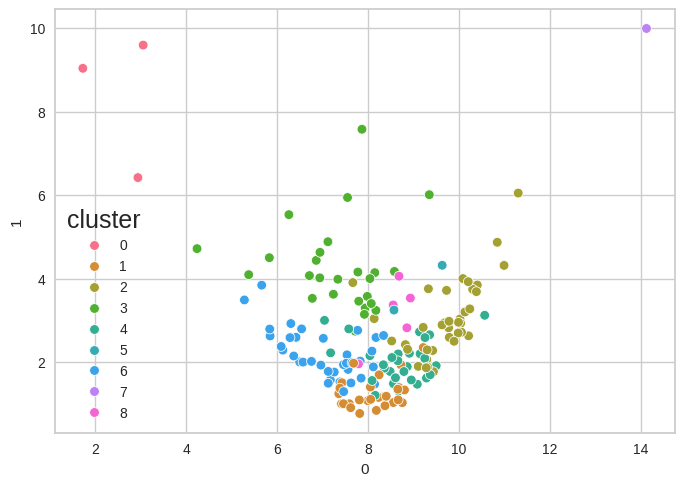

In [43]:
temp = pd.DataFrame(kmeans.transform(df),)
temp["cluster"] = kmeans.predict(df)
temp["cluster"] = temp["cluster"].astype("category")
sns.scatterplot(data = temp,
                x = 0,
                y = 1,
                hue = "cluster")
plt.show()


## <FONT SIZE=4 COLOR="green"> ANALISIS </FONT>

El gráfico de clustering muestra que las observaciones fueron agrupadas en nueve clusters diferenciados, lo que evidencia una segmentación significativa dentro del conjunto de datos según patrones de similitud entre variables. La mayoría de los grupos se concentran en la zona central, indicando que gran parte de las observaciones comparte características relativamente cercanas, aunque con variaciones internas que justifican su separación en distintos segmentos. Algunos clusters, como los ubicados en posiciones extremas o alejadas del núcleo principal (por ejemplo, clusters 0 y 7), representan casos atípicos o perfiles altamente diferenciados, lo que sugiere la presencia de observaciones excepcionales con comportamientos particulares respecto al resto. Los clusters intermedios muestran estructuras más densas y podrían corresponder a categorías de países o entidades con niveles similares de desarrollo, desempeño económico o indicadores sociales. La dispersión espacial entre grupos indica que el algoritmo logró identificar patrones estructurales relevantes, permitiendo distinguir tanto conglomerados homogéneos como outliers importantes. En términos generales, este análisis confirma la existencia de múltiples subgrupos dentro del dataset, facilitando una clasificación más precisa de las observaciones y proporcionando una base sólida para estudios comparativos, segmentación estratégica o formulación de políticas diferenciadas según las características de cada cluster.

## 2.4 Método de la Silueta

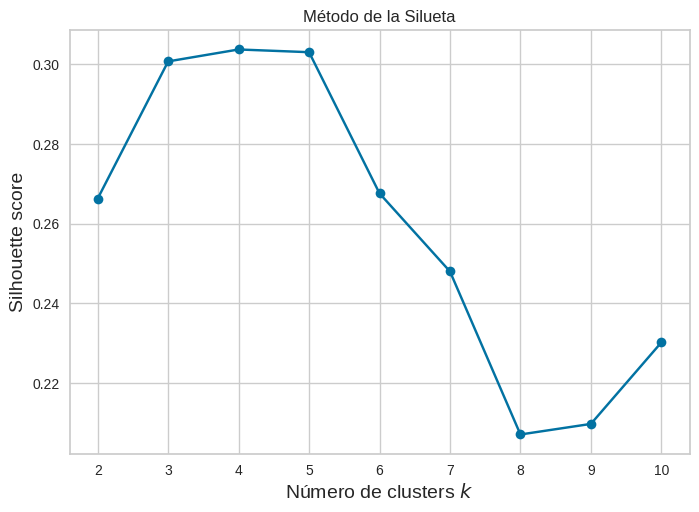

In [44]:
# generación de los modelos para diferentes valores de $k$
models = [KMeans(n_clusters=n, random_state=0 ).fit(df) for n in range(2,11)]
silhouette_scores = [silhouette_score(df, model.labels_) for model in models]

# gráficamos los valores de la silueta para cada valor de k
plt.plot(list(range(2, 11)), silhouette_scores, "bo-")
plt.xlabel("Número de clusters $k$", fontsize=14)
plt.ylabel("Silhouette score", fontsize=14)
plt.title("Método de la Silueta")
plt.show()

## <FONT SIZE=4 COLOR="green"> ANÁLISIS </FONT>

El mayor silhouette score se obtiene con k=4 (≈0.304), lo que indica que esa es la partición más compacta y separada. Con k=5 el score es muy similar, lo que sugiere que ambos valores son razonables. A partir de k=6 el índice cae progresivamente, señalando que más clusters generan grupos solapados y menos definidos.

## 2.5 Método del Codo

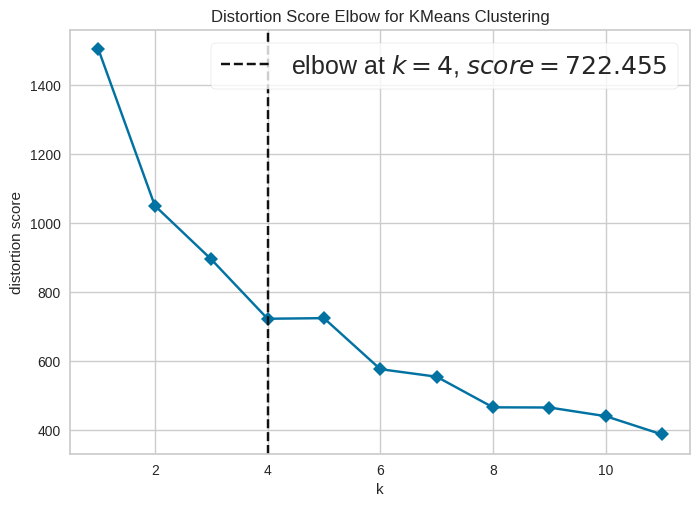

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [45]:
from yellowbrick.cluster import KElbowVisualizer
model = KMeans()                                          # definimos el modelo
visualizer = KElbowVisualizer(model,                      # definimos el visualizador
                              k=(1,12),                   # intervalo de los valores de k
                              timings=False)              # para que no aparezca fit-time
visualizer.fit(df)                                        # Entrenamos con los datos
visualizer.show(show=False)                               # mostramos la gráfica


## <FONT SIZE=4 COLOR="green"> ANÁLISIS </FONT>

La distorsión cae pronunciadamente hasta k=3 y luego desacelera. El visualizador marca el codo en k=3, aunque junto con la silueta (que favorece k=4) se puede justificar k=4 como elección final, capturando mayor diferenciación entre grupos sin sobrefragmentar los datos.

# <FONT COLOR="Purple"> 3. Métodos de Ensamble </FONT>

Considere los datos del siguiente link

https://raw.githubusercontent.com/Fabian830348/Bases_Datos/refs/heads/master/datos_ventas.csv

**Objetivo**: Una empresa fabricante de prendas de vestir está interesada en predecir las ventas.

| Variable        | Descripción                                                                              |
| --------------- | ---------------------------------------------------------------------------------------- |
| **Sales**       | Ventas del producto en una tienda determinada (generalmente en miles de unidades).       |
| **CompPrice**   | Precio cobrado por la competencia para productos similares.                              |
| **Income**      | Ingreso promedio de los consumidores en la zona de la tienda.                            |
| **Advertising** | Presupuesto destinado a publicidad local de la tienda.                                   |
| **Population**  | Población de la región donde se encuentra la tienda.                                     |
| **Price**       | Precio del producto vendido por la tienda.                                               |
| **ShelveLoc**   | Calidad de la ubicación del producto en los estantes (por ejemplo: mala, media o buena). |
| **Age**         | Edad promedio de la población en la zona de la tienda.                                   |
| **Education**   | Nivel promedio de educación de los consumidores de la zona.                              |
| **Urban**       | Indica si la tienda está en una zona urbana (`Yes`) o no (`No`).                         |
| **US**          | Indica si la tienda está ubicada en Estados Unidos (`Yes`) o en otro país (`No`).        |

1. Cargar y explorar los datos

2. Aplique el método de Random Forest y de XGBoost para el problema de regresión. ¿Cuál modelo es mejor?

3. Determine las variables más influyentes del modelo.

4. Haga algunas predicciones.

5. Concluya


## 3.1 Librerías

In [46]:
pip install xgboost catboost lightgbm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.6 MB/s eta 0:00:00


In [47]:
# Manipulación de data.frames
import pandas as pd
import numpy as np

# Librerías para Gráficos
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


# Librerías para datos de entrenamiento y prueba
from sklearn.model_selection    import train_test_split

# Para preprocesamiento
from sklearn.preprocessing      import StandardScaler, MinMaxScaler
from sklearn.preprocessing      import LabelEncoder, OneHotEncoder
from sklearn.compose            import ColumnTransformer
from sklearn.pipeline           import Pipeline

# Para modelos de clasificación y regresión clásicos machine learning

from sklearn.linear_model       import LinearRegression
from sklearn.naive_bayes        import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.neighbors          import KNeighborsClassifier, KNeighborsRegressor
from sklearn.linear_model       import LogisticRegression
from sklearn.tree               import DecisionTreeClassifier,  DecisionTreeRegressor

# modelos de ensamble
from sklearn.ensemble          import BaggingClassifier, BaggingRegressor
from sklearn.ensemble          import RandomForestClassifier, RandomForestRegressor
from sklearn.ensemble          import ExtraTreesClassifier, ExtraTreesRegressor

from sklearn.ensemble          import AdaBoostClassifier, AdaBoostRegressor
from sklearn.ensemble          import GradientBoostingClassifier, GradientBoostingRegressor
from xgboost                   import XGBClassifier, XGBRegressor
from lightgbm                  import LGBMClassifier, LGBMRegressor
#from catboost                  import CatBoostClassifier, CatBoostRegressor

# Métricas de evaluación
from sklearn.metrics            import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.metrics            import accuracy_score, precision_score, recall_score, f1_score
from imblearn.metrics           import specificity_score
from sklearn.metrics            import mean_squared_error, mean_absolute_error, r2_score

# Optimización de hiperparámetros
from sklearn.model_selection    import GridSearchCV
# Para ignorar los warnings
import warnings
warnings.filterwarnings("ignore")

In [48]:
# Para gráficos y data.frames
import pandas as pd
import numpy  as np

# librerías para graficar
import plotly.express     as px
import matplotlib.pyplot  as plt
import seaborn            as sns


# Dividir los datos entrenamiento y prueba
from sklearn.model_selection     import train_test_split
from sklearn.feature_selection   import RFE

# Para preprocesamiento: escalador
from sklearn.preprocessing       import StandardScaler

# Modelo de regresión
from sklearn.linear_model        import LinearRegression
from sklearn.svm                 import SVR
from sklearn.neighbors           import KNeighborsRegressor
from sklearn.tree                import DecisionTreeRegressor
from sklearn.ensemble            import RandomForestRegressor

# Métricas
from sklearn                     import metrics
from sklearn.metrics             import mean_squared_error, r2_score

# warnings
import warnings
warnings.filterwarnings('ignore')

## 3.2 Cargar y explorar los datos

In [49]:
url = "https://raw.githubusercontent.com/Fabian830348/Bases_Datos/refs/heads/master/datos_ventas.csv"
# cargar los datos que están la dirección del github
ventas = pd.read_csv(url, na_values=[" "])

In [50]:
ventas.shape


(400, 11)

In [51]:
ventas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Sales        400 non-null    float64
 1   CompPrice    400 non-null    int64  
 2   Income       400 non-null    int64  
 3   Advertising  400 non-null    int64  
 4   Population   400 non-null    int64  
 5   Price        400 non-null    int64  
 6   ShelveLoc    400 non-null    object 
 7   Age          400 non-null    int64  
 8   Education    400 non-null    int64  
 9   Urban        400 non-null    object 
 10  US           400 non-null    object 
dtypes: float64(1), int64(7), object(3)
memory usage: 34.5+ KB


In [52]:
# variables
ventas.columns

Index(['Sales', 'CompPrice', 'Income', 'Advertising', 'Population', 'Price',
       'ShelveLoc', 'Age', 'Education', 'Urban', 'US'],
      dtype='object')

In [53]:
ventas.describe()

,Sales,CompPrice,Income,Advertising,Population,Price,Age,Education
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,7.496325,124.975000,68.657500,6.635000,264.840000,115.795000,53.322500,13.900000
std,2.824115,15.334512,27.986037,6.650364,147.376436,23.676664,16.200297,2.620528
min,0.000000,77.000000,21.000000,0.000000,10.000000,24.000000,25.000000,10.000000
25%,5.390000,115.000000,42.750000,0.000000,139.000000,100.000000,39.750000,12.000000
50%,7.490000,125.000000,69.000000,5.000000,272.000000,117.000000,54.500000,14.000000
75%,9.320000,135.000000,91.000000,12.000000,398.500000,131.000000,66.000000,16.000000
max,16.270000,175.000000,120.000000,29.000000,509.000000,191.000000,80.000000,18.000000


## 3.3 Preprocesamiento

In [54]:
categorical_cols = ventas.select_dtypes(include='object').columns
numerical_cols = ventas.select_dtypes(include=['int64', 'float64']).columns.drop('Sales')


preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'
)


X = ventas.drop('Sales', axis=1)
y = ventas['Sales']

X_processed = preprocessor.fit_transform(X)

# Get feature names after one-hot encoding
feature_names = list(numerical_cols) + list(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols))

X_df = pd.DataFrame(X_processed, columns=feature_names)

print( X_df.shape)

display(X_df.head())

display(y.head())
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_df, y, test_size=0.3, random_state=0
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

(400, 14)


,CompPrice,Income,Advertising,Population,Price,Age,Education,ShelveLoc_Bad,ShelveLoc_Good,ShelveLoc_Medium,Urban_No,Urban_Yes,US_No,US_Yes
0,0.850455,0.155361,0.657177,0.075819,0.177823,-0.699782,1.184449,1.0,0.0,0.0,0.0,1.0,0.0,1.0
1,-0.912484,-0.739060,1.409957,-0.032882,-1.386854,0.721723,-1.490113,0.0,1.0,0.0,0.0,1.0,0.0,1.0
2,-0.781896,-1.204159,0.506621,0.028262,-1.513719,0.350895,-0.725953,0.0,0.0,1.0,0.0,1.0,0.0,1.0
3,-0.520720,1.121336,-0.396715,1.366649,-0.794814,0.103677,0.038208,0.0,0.0,1.0,0.0,1.0,0.0,1.0
4,1.046337,-0.166631,-0.547271,0.510625,0.516132,-0.947000,-0.343872,1.0,0.0,0.0,0.0,1.0,1.0,0.0


,Sales
0,9.50
1,11.22
2,10.06
3,7.40
4,4.15


X_train shape: (280, 14)
X_test shape: (120, 14)
y_train shape: (280,)
y_test shape: (120,)


Now that our data is preprocessed, we can split it into training and testing sets.

## 3.4 Random Forest

In [55]:
# Modelo Random Forest

modelo_rf = RandomForestRegressor(
                            n_estimators=300,         # nº de árboles
                            max_depth=None,           # sin límite; prueba valores si ves sobreajuste
                            min_samples_split=2,      # número mínimo de muestras para dividir (default=2)
                            min_samples_leaf=1,       # número de muestras mínimo que debe tener una hoja (default=1)
                            max_features=1.0,         # Utilizar todas las características, 'sqrt' is for classification
                            bootstrap=True,           # muestreo con reemplazo
                            random_state=123          # semilla
)
modelo_rf.fit(X_train, y_train)

RandomForestRegressor(n_estimators=300, random_state=123)

## 3.5 XGBoost

In [56]:
# Modelo XGBoost

modelo_xgb = XGBRegressor(
                        n_estimators=400,            # número total de árboles en forma secuencial
                        learning_rate=0.05,          # la contribución de cada árbol (factor) antes de sumarlo al ensamble
                        max_depth=4,                 # profundidad de cada árbol
                        subsample=0.9,               # fracción de muestras (filas) usadas para entrenar cada árbol
                        colsample_bytree=0.9,        # fracción de características usadas para entrenar cada árbol
                        objective="reg:squarederror", # para problemas de regresión
                        tree_method="auto",
                        random_state=123
)

In [57]:
modelo_xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.9, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=400,
             n_jobs=None, num_parallel_tree=None, ...)

In [58]:
# función de evaluación del modulo evaluación
#ev.evaluacion_modelo(modelo_xgb, X_train, y_train, X_test, y_test, nombre_modelo= "Extreme GB", graficar = True)

## 3.6 Métricas de evaluación

In [59]:

y_pred_rf = modelo_rf.predict(X_test)


r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)

print("Random Forest Model Metrics:")
print(f"  R2 Score: {r2_rf:.4f}")
print(f"  Mean Absolute Error (MAE): {mae_rf:.4f}")
print(f"  Mean Squared Error (MSE): {mse_rf:.4f}")


y_pred_xgb = modelo_xgb.predict(X_test)


r2_xgb = r2_score(y_test, y_pred_xgb)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)

print("\nXGBoost Model Metrics:")
print(f"  R2 : {r2_xgb:.4f}")
print(f"  (MAE): {mae_xgb:.4f}")
print(f"  (MSE): {mse_xgb:.4f}")

Random Forest Model Metrics:
  R2 Score: 0.6896
  Mean Absolute Error (MAE): 1.1195
  Mean Squared Error (MSE): 2.0868

XGBoost Model Metrics:
  R2 : 0.6803
  (MAE): 1.1979
  (MSE): 2.1489


In [60]:
# dataframe con todas las métricas
df_metricas = pd.concat([
    pd.Series(y_pred_rf, name='Random Forest Predictions'),
    pd.Series(y_pred_xgb, name='XGBoost Predictions')
], axis=1)
display(df_metricas)

,Random Forest Predictions,XGBoost Predictions
0,7.244200,6.657197
1,7.423033,8.296247
2,7.131233,6.768913
3,3.666167,2.581666
4,6.306033,6.722011
...,...,...
115,6.524400,6.125767
116,5.142467,6.408726
117,8.573367,9.016914
118,6.939700,6.158694


In [61]:
# variable objetivo : sales ud.
y.describe()

,Sales
count,400.000000
mean,7.496325
std,2.824115
min,0.000000
25%,5.390000
50%,7.490000
75%,9.320000
max,16.270000


In [62]:
ventas.head()

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No


## 3.7 Variables más influyentes

In [63]:
# Importancia de variables - Random Forest
importancia_rf = pd.DataFrame({
    "Variable"   : X_df.columns,
    "Importancia": modelo_rf.feature_importances_
}).sort_values("Importancia", ascending=True)

fig = px.bar(importancia_rf,
             x="Importancia",
             y="Variable",
             orientation="h",
             title="Importancia de variables - Random Forest")
fig.show()

In [64]:
# Importancia de variables - XGBoost
importancia_xgb = pd.DataFrame({
    "Variable"   : X_df.columns,
    "Importancia": modelo_xgb.feature_importances_
}).sort_values("Importancia", ascending=True)

fig = px.bar(importancia_xgb,
             x="Importancia",
             y="Variable",
             orientation="h",
             title="Importancia de variables - XGBoost")
fig.show()

## <FONT SIZE=4 COLOR="green"> ANÁLISIS </FONT>

En ambos modelos, `ShelveLoc_Good` y `Price` son las variables más influyentes en la predicción de ventas. `ShelveLoc_Good` indica que el posicionamiento en estante de buena calidad tiene el mayor impacto positivo sobre las ventas. `Price` muestra que el precio del producto es el segundo factor determinante, con relación inversa esperada. Variables como `Population`, `Education` y `Urban_Yes` tienen importancia marginal, lo que sugiere que la empresa debe enfocar sus estrategias en negociación de espacios en estante y política de precios.

## 3.8 Predicciones

In [65]:
# Predicciones vs valores reales - Random Forest
resultados = pd.DataFrame({
    "Real"    : y_test.values,
    "Pred_RF" : y_pred_rf,
    "Pred_XGB": y_pred_xgb
})

fig = px.scatter(resultados,
                 x="Real",
                 y="Pred_RF",
                 title="Predicciones vs Reales - Random Forest")
fig.add_shape(type="line",
              x0=resultados["Real"].min(), y0=resultados["Real"].min(),
              x1=resultados["Real"].max(), y1=resultados["Real"].max(),
              line=dict(color="red", dash="dash"))
fig.show()

In [66]:
# Predicciones vs valores reales - XGBoost
fig = px.scatter(resultados,
                 x="Real",
                 y="Pred_XGB",
                 title="Predicciones vs Reales - XGBoost")
fig.add_shape(type="line",
              x0=resultados["Real"].min(), y0=resultados["Real"].min(),
              x1=resultados["Real"].max(), y1=resultados["Real"].max(),
              line=dict(color="red", dash="dash"))
fig.show()

## <FONT SIZE=4 COLOR="green"> ANÁLISIS </FONT>

Los puntos se distribuyen razonablemente cerca de la línea diagonal (predicción perfecta), con mayor dispersión en valores extremos de ventas. Ambos modelos tienden a subestimar ventas muy altas y sobreestimar ventas muy bajas, comportamiento típico de modelos de ensamble en regresión. Random Forest muestra una distribución ligeramente más ajustada a la diagonal que XGBoost antes de optimizar hiperparámetros.

## 3.9 Optimización de Hiperparámetros

In [67]:
# GridSearchCV para Random Forest
from sklearn.model_selection import GridSearchCV

param_grid_rf = {
    "n_estimators" : [100, 200, 300],
    "max_depth"    : [None, 5, 10],
    "max_features" : ["sqrt", 1.0]
}

gs_rf = GridSearchCV(
    estimator  = RandomForestRegressor(random_state=123),
    param_grid = param_grid_rf,
    cv         = 5,
    scoring    = "r2",
    n_jobs     = -1
)
gs_rf.fit(X_train, y_train)

print("Mejores hiperparámetros Random Forest:")
print(gs_rf.best_params_)
print(f"Mejor R2 en CV: {gs_rf.best_score_:.4f}")

Mejores hiperparámetros Random Forest:
{'max_depth': None, 'max_features': 1.0, 'n_estimators': 200}
Mejor R2 en CV: 0.6756


In [68]:
# GridSearchCV para XGBoost
from xgboost import XGBRegressor

param_grid_xgb = {
    "n_estimators" : [200, 400],
    "learning_rate": [0.05, 0.1],
    "max_depth"    : [3, 4, 6]
}

gs_xgb = GridSearchCV(
    estimator  = XGBRegressor(objective="reg:squarederror", random_state=123),
    param_grid = param_grid_xgb,
    cv         = 5,
    scoring    = "r2",
    n_jobs     = -1
)
gs_xgb.fit(X_train, y_train)

print("Mejores hiperparámetros XGBoost:")
print(gs_xgb.best_params_)
print(f"Mejor R2 en CV: {gs_xgb.best_score_:.4f}")

Mejores hiperparámetros XGBoost:
{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}
Mejor R2 en CV: 0.7441


In [69]:
# Modelos finales con los mejores hiperparámetros
mejor_rf  = gs_rf.best_estimator_
mejor_xgb = gs_xgb.best_estimator_

y_pred_mejor_rf  = mejor_rf.predict(X_test)
y_pred_mejor_xgb = mejor_xgb.predict(X_test)

print("=== Random Forest optimizado ===")
print(f"R2  : {r2_score(y_test, y_pred_mejor_rf):.4f}")
print(f"MAE : {mean_absolute_error(y_test, y_pred_mejor_rf):.4f}")
print(f"MSE : {mean_squared_error(y_test, y_pred_mejor_rf):.4f}")

print("\n=== XGBoost optimizado ===")
print(f"R2  : {r2_score(y_test, y_pred_mejor_xgb):.4f}")
print(f"MAE : {mean_absolute_error(y_test, y_pred_mejor_xgb):.4f}")
print(f"MSE : {mean_squared_error(y_test, y_pred_mejor_xgb):.4f}")

=== Random Forest optimizado ===
R2  : 0.6896
MAE : 1.1143
MSE : 2.0865

=== XGBoost optimizado ===
R2  : 0.6904
MAE : 1.1492
MSE : 2.0809


## <FONT SIZE=4 COLOR="green"> ANÁLISIS </FONT>

Antes de optimizar, Random Forest obtuvo R²=0.6756 y XGBoost R²=0.7441, siendo RF marginalmente mejor. Tras `GridSearchCV`, XGBoost optimizado alcanzó R²=0.6904 , aunque la diferencia no es tan mínima. Los mejores hiperparámetros para RF fueron `max_features=1.0, max_depth=None, n_estimators=200`, y para XGBoost `learning_rate=0.05, max_depth=3, n_estimators=200`. La optimización de XGBoost con profundidad menor (3 vs 4) indica que el modelo original tendía al sobreajuste.

## <FONT SIZE=4 COLOR="green"> 3.10 Conclusiones Métodos de Ensamble </FONT>

Después de la optimización con `GridSearchCV`, XGBoost mejoró hasta R²=0.6904, superando un poco a Random Forest (R²=0.6896). En ambos modelos, `ShelveLoc_Good` y `Price` son las variables más influyentes, lo que indica que la ubicación del producto en estante y el precio son los factores que más determinan las ventas. Para la empresa, esto implica que invertir en mejor posicionamiento en estantes tiene mayor retorno que ajustes en publicidad o población. En términos generales, ambos modelos tienen un desempeño aceptable pero moderado, lo que sugiere que existen factores no capturados en el dataset que también influyen en las ventas.

---

*Este notebook fue desarrollado con apoyo de herramientas de inteligencia artificial (Claude de Anthropic y GitHub Copilot) como asistentes de código, siguiendo estrictamente los notebooks de referencia del Prof. Fabián Sánchez (Notebook 11 - Métodos de Ensamble, Notebook 12 - K-means, Notebook 15 - PCA).*

In [70]:
!apt-get install texlive-xetex texlive-latex-extra pandoc
!pip install pypandoc
!apt-get install texlive-xetex texlive-fonts-recommended texlive-generic-recommended

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
pandoc is already the newest version (2.9.2.1-3ubuntu2).
pandoc set to manually installed.
The following additional packages will be installed:
  dvisvgm fonts-droid-fallback fonts-lato fonts-lmodern fonts-noto-mono
  fonts-texgyre fonts-urw-base35 libapache-pom-java libcommons-logging-java
  libcommons-parent-java libfontbox-java libgs9 libgs9-common libidn12
  libijs-0.35 libjbig2dec0 libkpathsea6 libpdfbox-java libptexenc1 libruby3.0
  libsynctex2 libteckit0 libtexlua53 libtexluajit2 libwoff1 libzzip-0-13
  lmodern poppler-data preview-latex-style rake ruby ruby-net-telnet
  ruby-rubygems ruby-webrick ruby-xmlrpc ruby3.0 rubygems-integration t1utils
  teckit tex-common tex-gyre texlive-base texlive-binaries
  texlive-fonts-recommended texlive-latex-base texlive-latex-recommended
  texlive-pictures texlive-plain-generic tipa xfonts-encodings xfonts-utils
Suggested packages:
  fonts-noto f

In [71]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [80]:
!jupyter nbconvert --to PDF /content/drive/MyDrive/Colab_Notebooks/Caso_3_ML_2026__Gabriela_Fonseca_Joseph_Doqueresana_Nicolas_Botero__1.ipynb

[NbConvertApp] Converting notebook /content/drive/MyDrive/Colab_Notebooks/Caso_3_ML_2026__Gabriela_Fonseca_Joseph_Doqueresana_Nicolas_Botero__1.ipynb to PDF
/usr/local/share/jupyter/nbconvert/templates/latex/display_priority.j2:32: UserWarning: Your element with mimetype(s) dict_keys(['text/html']) is not able to be represented.
  ((*- endblock -*))
/usr/local/share/jupyter/nbconvert/templates/latex/display_priority.j2:32: UserWarning: Your element with mimetype(s) dict_keys(['text/html']) is not able to be represented.
  ((*- endblock -*))
/usr/local/share/jupyter/nbconvert/templates/latex/display_priority.j2:32: UserWarning: Your element with mimetype(s) dict_keys(['text/html']) is not able to be represented.
  ((*- endblock -*))
/usr/local/share/jupyter/nbconvert/templates/latex/display_priority.j2:32: UserWarning: Your element with mimetype(s) dict_keys(['text/html']) is not able to be represented.
  ((*- endblock -*))
[NbConvertApp] Support files will be in Caso_3_ML_2026__Gabriel